## Chapter V.1. Теоретические вопросы

### 1.1. Аналитическое решение регрессии

Задача — минимизировать MSE по параметрам $\theta \in \mathbb{R}^{d+1}$ (объединяем веса $\mathbf{w}$ и bias $b$, добавляя к $X$ столбец единиц):

$$L(\theta) = \frac{1}{N}\|\mathbf{y} - X\theta\|_2^2 = \frac{1}{N}(\mathbf{y}-X\theta)^T(\mathbf{y}-X\theta)$$

Раскроем скобки:

$$L(\theta) = \frac{1}{N}\left(\mathbf{y}^T\mathbf{y} - 2\theta^T X^T \mathbf{y} + \theta^T X^T X \theta\right)$$

Берём градиент и приравниваем к нулю:

$$\nabla_\theta L = \frac{2}{N}\left(X^T X \theta - X^T \mathbf{y}\right) = 0 \quad\Rightarrow\quad X^T X \theta = X^T \mathbf{y}$$

Откуда:

$$\boxed{\hat\theta = (X^T X)^{-1} X^T \mathbf{y}}$$

### 1.2. Что изменится при L1 / L2 регуляризации

**L2 (Ridge):** лосс превращается в

$$L(\theta) = \frac{1}{N}\|\mathbf{y} - X\theta\|_2^2 + \lambda\|\theta\|_2^2$$

Градиент даёт систему $(X^T X + N\lambda I)\,\theta = X^T \mathbf{y}$, откуда

$$\hat\theta_{ridge} = (X^T X + N\lambda I)^{-1} X^T \mathbf{y}$$

То есть добавка $\lambda I$ делает матрицу всегда обратимой и "штрафует" большие веса — решение остаётся замкнутым.

**L1 (Lasso):** лосс

$$L(\theta) = \frac{1}{N}\|\mathbf{y} - X\theta\|_2^2 + \lambda\|\theta\|_1$$

Здесь $\|\theta\|_1$ **не дифференцируема** в нуле, аналитического решения нет. Используют итеративные методы.

### 1.3. Почему L1 обнуляет веса (feature selection)

Геометрически: L1-шар — это "ромб" (в 2D квадрат, повёрнутый на 45°) с углами на осях. Линии уровня квадратичного лосса — эллипсы. Оптимум лассо — точка касания эллипса и ромба; из-за "острых" углов эта точка с большой вероятностью попадает на угол, где часть координат **ровно ноль**.


L2 же штрафует квадрат веса - сфера, которая касается эллипса не в осевых точках

### 1.4. Как линейная модель ловит нелинейные зависимости

Нужно применить к входам нелинейное преобразование $\varphi(x)$ — модель остаётся **линейной по параметрам**, но нелинейной по исходным признакам:

$$f(x) = \mathbf{w}^T \varphi(x) + b$$


## Chapter V.2. Введение — загрузка данных

In [260]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
np.set_printoptions(precision=4, suppress=True)

SEED = 21
np.random.seed(SEED)

In [261]:
train_df = pd.read_json("./data/train.json")
test_df  = pd.read_json("./data/test.json")
print("train:", train_df.shape, " test:", test_df.shape)
train_df.head(3)

train: (49352, 15)  test: (74659, 14)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium


In [262]:
p1, p99 = train_df["price"].quantile([0.01, 0.99])
print(f"price range kept: [{p1:.0f}; {p99:.0f}]")

train_df = train_df[train_df["price"].between(p1, p99)].reset_index(drop=True)
test_df  = test_df [test_df ["price"].between(p1, p99)].reset_index(drop=True)
print("after price-outlier removal — train:", train_df.shape, " test:", test_df.shape)

for col in ("bathrooms", "bedrooms"):
    lo, hi = train_df[col].min(), train_df[col].max()
    test_df[col] = test_df[col].clip(lo, hi)

price range kept: [1475; 13000]
after price-outlier removal — train: (48379, 15)  test: (73255, 14)


## Chapter V.3. Intro data analysis — генерация признаков из `features`

In [263]:
train_df["features"].head(5).tolist()

[['Dining Room',
  'Pre-War',
  'Laundry in Building',
  'Dishwasher',
  'Hardwood Floors',
  'Dogs Allowed',
  'Cats Allowed'],
 ['Doorman',
  'Elevator',
  'Laundry in Building',
  'Dishwasher',
  'Hardwood Floors',
  'No Fee'],
 ['Doorman',
  'Elevator',
  'Laundry in Building',
  'Laundry in Unit',
  'Dishwasher',
  'Hardwood Floors'],
 [],
 ['Doorman', 'Elevator', 'Fitness Center', 'Laundry in Building']]

In [264]:
BAD_CHARS = str.maketrans("", "", "[]\'\" ")

def clean_feature_list(lst):
    return [s.translate(BAD_CHARS) for s in lst if str(s).strip()]

train_df["features"] = train_df["features"].apply(clean_feature_list)
test_df ["features"] = test_df ["features"].apply(clean_feature_list)
train_df["features"].head(3).tolist()

[['DiningRoom',
  'Pre-War',
  'LaundryinBuilding',
  'Dishwasher',
  'HardwoodFloors',
  'DogsAllowed',
  'CatsAllowed'],
 ['Doorman',
  'Elevator',
  'LaundryinBuilding',
  'Dishwasher',
  'HardwoodFloors',
  'NoFee'],
 ['Doorman',
  'Elevator',
  'LaundryinBuilding',
  'LaundryinUnit',
  'Dishwasher',
  'HardwoodFloors']]

In [265]:
# Сбор всех значений в один список
huge_list = []
for _, row in train_df.iterrows():
    huge_list.extend(row["features"])

print("total values:", len(huge_list))
print("unique values:", len(set(huge_list)))

total values: 262573
unique values: 1529


In [266]:
# Collections.Counter для топ-20
counter = Counter(huge_list)
top20 = [name for name, _ in counter.most_common(20)]
print(top20)

['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


In [267]:
expected = {"Elevator","CatsAllowed","HardwoodFloors","DogsAllowed","Doorman",
            "Dishwasher","NoFee","LaundryinBuilding","FitnessCenter","Pre-War",
            "LaundryinUnit","RoofDeck","OutdoorSpace","DiningRoom","HighSpeedInternet",
            "Balcony","SwimmingPool","LaundryInBuilding","NewConstruction","Terrace"}
missing = expected - set(top20)
extra   = set(top20) - expected
print("missing from expected:", missing)
print("extra vs expected   :", extra)

missing from expected: set()
extra vs expected   : set()


In [268]:
# Создание 20 бинарных фичей по топ-20
def add_top_features(df, top):
    df = df.copy()
    feats_sets = df["features"].apply(set)
    for name in top:
        df[name] = feats_sets.apply(lambda s, n=name: int(n in s))
    return df

train_df = add_top_features(train_df, top20)
test_df  = add_top_features(test_df , top20)

feature_list = top20 + ["bathrooms", "bedrooms"]
print(f"features total: {len(feature_list)}")
feature_list

features total: 22


['Elevator',
 'HardwoodFloors',
 'CatsAllowed',
 'DogsAllowed',
 'Doorman',
 'Dishwasher',
 'NoFee',
 'LaundryinBuilding',
 'FitnessCenter',
 'Pre-War',
 'LaundryinUnit',
 'RoofDeck',
 'OutdoorSpace',
 'DiningRoom',
 'HighSpeedInternet',
 'Balcony',
 'SwimmingPool',
 'LaundryInBuilding',
 'NewConstruction',
 'Terrace',
 'bathrooms',
 'bedrooms']

In [269]:
X_train = train_df[feature_list].astype(float).values
y_train = train_df["price"].astype(float).values
X_test  = test_df [feature_list].astype(float).values
y_test  = test_df ["price"].astype(float).values
print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (48379, 22)  X_test: (73255, 22)


## Chapter V.4. Реализация Linear Regression

Три варианта:

- **Analytical** — формула $\hat\theta = (X^T X)^{-1} X^T y$.
- **Full-batch GD** — детерминированный градиентный спуск.
- **SGD** — стохастический спуск. Определённость (determenism) даётся фиксацией `random_state` у генератора перестановок.

In [270]:
class MyLinearRegressionAnalytical:
    # w = (X^T X)^{-1} X^T y. Через lstsq для численной устойчивости.
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        Xb = np.hstack([np.ones((len(X), 1)), X])
        theta, *_ = np.linalg.lstsq(Xb, y, rcond=None)
        self.intercept_ = theta[0]
        self.coef_      = theta[1:]
        return self
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_


class MyLinearRegressionGD:
    # Full-batch GD по MSE.
    def __init__(self, lr=0.01, n_epochs=500, tol=1e-7, verbose=False):
        self.lr, self.n_epochs, self.tol, self.verbose = lr, n_epochs, tol, verbose
    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=float)
        n, d = X.shape
        Xb = np.hstack([np.ones((n, 1)), X])
        theta = np.zeros(d + 1)
        prev_loss = np.inf
        self.history_ = []
        for ep in range(self.n_epochs):
            pred = Xb @ theta
            grad = -(2.0 / n) * Xb.T @ (y - pred)
            theta -= self.lr * grad
            loss = np.mean((y - pred) ** 2)
            self.history_.append(loss)
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss
        self.intercept_ = theta[0]
        self.coef_      = theta[1:]
        return self
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_


class MyLinearRegressionSGD:
    # Mini-batch SGD с фиксированным seed => детерминирован. Поддерживает l1/l2 регуляризации.
    # Дефолты: lr=0.05 с decay lr_t = lr / (1 + t * lr_decay), batch_size=256, 50 эпох.
    def __init__(self, lr=0.05, n_epochs=50, batch_size=256, lr_decay=1e-4,
                 l1=0.0, l2=0.0, random_state=SEED, tol=1e-8, verbose=False):
        self.lr = lr; self.n_epochs = n_epochs; self.batch_size = batch_size
        self.lr_decay = lr_decay
        self.l1 = l1; self.l2 = l2
        self.random_state = random_state; self.tol = tol; self.verbose = verbose

    def _loss(self, Xb, y, theta):
        resid = y - Xb @ theta
        mse = np.mean(resid ** 2)
        reg = self.l2 * np.sum(theta[1:] ** 2) + self.l1 * np.sum(np.abs(theta[1:]))
        return mse + reg

    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=float)
        n, d = X.shape
        Xb = np.hstack([np.ones((n, 1)), X])
        theta = np.zeros(d + 1)
        rng = np.random.default_rng(self.random_state)  # детерминированный RNG
        prev = np.inf
        self.history_ = []
        t = 0
        for ep in range(self.n_epochs):
            idx = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                sl = idx[start:start + self.batch_size]
                xb = Xb[sl]; yb = y[sl]
                resid = yb - xb @ theta
                grad = -(2.0 / len(sl)) * xb.T @ resid
                # регуляризации (не штрафуем bias theta[0])
                if self.l2:
                    reg_grad = 2.0 * self.l2 * theta
                    reg_grad[0] = 0.0
                    grad = grad + reg_grad
                if self.l1:
                    sub = np.sign(theta)
                    sub[0] = 0.0
                    grad = grad + self.l1 * sub
                lr_t = self.lr / (1.0 + t * self.lr_decay)
                theta -= lr_t * grad
                t += 1
            cur = self._loss(Xb, y, theta)
            self.history_.append(cur)
            if self.verbose and ep % max(1, self.n_epochs // 10) == 0:
                print(f"  epoch {ep:3d}  loss={cur:.4f}")
            if abs(prev - cur) < self.tol:
                break
            prev = cur
        self.intercept_ = theta[0]
        self.coef_      = theta[1:]
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_

### Что значит "детерминированная модель"?

Модель называют детерминированной, если при одинаковых данных и одинаковых гиперпараметрах она всегда выдаёт один и тот же результат. Для SGD это достигается фиксацией seed генератора случайных чисел (`np.random.default_rng(random_state)`) — отсюда одинаковый порядок прохода объектов между запусками.

### Реализация R²

$$R^2 = 1 - \dfrac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}$$

R² = 1 — идеальное предсказание, R² = 0 — модель как константа $\bar y$, R² < 0 — хуже константы.

In [271]:
def r2_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

### Обучение и сравнение с sklearn

In [272]:
# Вспомогательная табличка результатов
result_mae  = pd.DataFrame(columns=["model", "train", "test"])
result_rmse = pd.DataFrame(columns=["model", "train", "test"])
result_r2   = pd.DataFrame(columns=["model", "train", "test"])

def add_metrics(name, y_tr, yhat_tr, y_te, yhat_te):
    result_mae .loc[len(result_mae )] = [name, mean_absolute_error(y_tr, yhat_tr), mean_absolute_error(y_te, yhat_te)]
    result_rmse.loc[len(result_rmse)] = [name, rmse                (y_tr, yhat_tr), rmse                (y_te, yhat_te)]
    result_r2  .loc[len(result_r2  )] = [name, r2_coefficient      (y_tr, yhat_tr), r2_coefficient      (y_te, yhat_te)]

In [273]:
# --- Мой аналитический ---
my_lr = MyLinearRegressionAnalytical().fit(X_train, y_train)
yhat_tr = my_lr.predict(X_train); yhat_te = my_lr.predict(X_test)
print(f"my_linear_analytical  MAE={mean_absolute_error(y_test, yhat_te):.2f}  "
      f"RMSE={rmse(y_test, yhat_te):.2f}  R2={r2_coefficient(y_test, yhat_te):.4f}")
add_metrics("my_linear_analytical", y_train, yhat_tr, y_test, yhat_te)

# --- sklearn LinearRegression ---
sk_lr = LinearRegression().fit(X_train, y_train)
yhat_tr = sk_lr.predict(X_train); yhat_te = sk_lr.predict(X_test)
print(f"sk_linear             MAE={mean_absolute_error(y_test, yhat_te):.2f}  "
      f"RMSE={rmse(y_test, yhat_te):.2f}  R2={r2_score(y_test, yhat_te):.4f}")
add_metrics("sk_linear", y_train, yhat_tr, y_test, yhat_te)

# Проверка совпадения коэффициентов
diff_coef = np.max(np.abs(my_lr.coef_ - sk_lr.coef_))
diff_int  = abs(my_lr.intercept_ - sk_lr.intercept_)
print(f"max |coef diff|: {diff_coef:.2e}  |intercept diff|: {diff_int:.2e}")

my_linear_analytical  MAE=714.43  RMSE=1036.07  R2=0.5756
sk_linear             MAE=714.43  RMSE=1036.07  R2=0.5756
max |coef diff|: 4.77e-11  |intercept diff|: 9.25e-11


## Chapter V.5. Регуляризованные модели — Ridge / Lasso / ElasticNet

In [274]:
class MyRidgeAnalytical:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    def fit(self, X, y):
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=float)
        n, d = X.shape
        Xb = np.hstack([np.ones((n, 1)), X])
        I = np.eye(d + 1); I[0, 0] = 0.0  # не регуляризуем bias
        A = Xb.T @ Xb + self.alpha * I
        theta = np.linalg.solve(A, Xb.T @ y)
        self.intercept_ = theta[0]; self.coef_ = theta[1:]
        return self
    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.coef_ + self.intercept_


def make_my_model(kind, **kw):
    if kind == "linear":
        return MyLinearRegressionSGD(**kw)
    if kind == "ridge":
        return MyLinearRegressionSGD(l2=kw.pop("alpha", 0.1), **kw)
    if kind == "lasso":
        return MyLinearRegressionSGD(l1=kw.pop("alpha", 0.1), **kw)
    if kind == "elastic":
        a = kw.pop("alpha", 0.1); r = kw.pop("l1_ratio", 0.5)
        return MyLinearRegressionSGD(l1=a*r, l2=a*(1-r), **kw)
    raise ValueError(kind)

### 5.2-5.5. Обучение регуляризованных моделей, метрики, сравнение с sklearn

In [275]:
# Мои реализации
my_ridge_an = MyRidgeAnalytical(alpha=1.0).fit(X_train, y_train)
add_metrics("my_ridge_analytical", y_train, my_ridge_an.predict(X_train),
                                   y_test,  my_ridge_an.predict(X_test))

for name, kind, params in [
    ("my_ridge_sgd",   "ridge",   {"alpha": 0.1}),
    ("my_lasso_sgd",   "lasso",   {"alpha": 0.1}),
    ("my_elastic_sgd", "elastic", {"alpha": 0.1, "l1_ratio": 0.5}),
]:
    m = make_my_model(kind, **params).fit(X_train, y_train)
    add_metrics(name, y_train, m.predict(X_train), y_test, m.predict(X_test))

# sklearn
for name, model in [
    ("sk_ridge",   Ridge(alpha=1.0, random_state=SEED)),
    ("sk_lasso",   Lasso(alpha=1.0, random_state=SEED, max_iter=10000)),
    ("sk_elastic", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=SEED, max_iter=10000)),
]:
    model.fit(X_train, y_train)
    add_metrics(name, y_train, model.predict(X_train), y_test, model.predict(X_test))

In [276]:
# Мини-таблица главы V.5: MAE / RMSE / R² — train и test.
ch5_models = ["my_ridge_analytical", "my_ridge_sgd", "my_lasso_sgd", "my_elastic_sgd",
              "sk_ridge", "sk_lasso", "sk_elastic"]

ch5_tbl = (result_mae .query("model in @ch5_models").rename(columns={"train": "MAE_train",  "test": "MAE_test"})
    .merge(result_rmse.query("model in @ch5_models").rename(columns={"train": "RMSE_train", "test": "RMSE_test"}), on="model")
    .merge(result_r2  .query("model in @ch5_models").rename(columns={"train": "R2_train",   "test": "R2_test"}),   on="model"))
print(ch5_tbl.to_string(index=False))

              model  MAE_train   MAE_test  RMSE_train   RMSE_test  R2_train  R2_test
my_ridge_analytical 711.787958 714.422138 1035.351581 1036.069672  0.580034 0.575596
       my_ridge_sgd 725.596922 727.651841 1072.634997 1071.946405  0.549243 0.545695
       my_lasso_sgd 710.247852 712.909115 1035.442032 1036.101619  0.579961 0.575570
     my_elastic_sgd 714.245933 716.478709 1050.298393 1050.072735  0.567821 0.564046
           sk_ridge 711.787958 714.422138 1035.351581 1036.069672  0.580034 0.575596
           sk_lasso 711.397534 714.010505 1035.548536 1036.118979  0.579874 0.575555
         sk_elastic 807.091322 809.074386 1189.928496 1187.999556  0.445272 0.442000


## Chapter V.6. Нормализация признаков

### Зачем нормализовать

- **Градиентные методы** (SGD, neural nets): без нормализации признак с большим масштабом доминирует, сходимость замедляется или расходится.
- **Regularized модели** (Ridge/Lasso): штраф $\|w\|$ несимметричен к масштабу — без нормализации признак с большим размахом штрафуется "меньше".
- **k-NN**: расстояния считаются в евклиде => большой масштаб = большой вклад.
- **PCA**: оси выбираются по дисперсии — без стандартизации берёт ось максимального масштаба.

### Когда нормализация не нужна (или даже вредна)

- **Древесные модели** (Decision Tree, Random Forest, Gradient Boosting): разбиения инвариантны к монотонным преобразованиям признаков.
- **Linear Regression без регуляризации (аналитически)**: решение инвариантно к линейному масштабированию.
- **Интерпретируемость исходных единиц** (денежные/временные величины, которые хочется читать как есть).

### MinMaxScaler

$$x'_j = \dfrac{x_j - \min(x_j)}{\max(x_j) - \min(x_j)} \in [0, 1]$$

### StandardScaler

$$x'_j = \dfrac{x_j - \mu_j}{\sigma_j}, \quad \mathbb{E}[x'] = 0,\ \mathrm{Var}[x'] = 1$$

In [277]:
class MyMinMaxScaler:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.min_ = X.min(axis=0)
        self.scale_ = X.max(axis=0) - self.min_
        # защита от нулевой дисперсии
        self.scale_ = np.where(self.scale_ == 0, 1.0, self.scale_)
        return self
    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.min_) / self.scale_
    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MyStandardScaler:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0, ddof=0)
        self.scale_ = np.where(self.scale_ == 0, 1.0, self.scale_)
        return self
    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.mean_) / self.scale_
    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [278]:
# Сравнение с sklearn
my_mm = MyMinMaxScaler().fit(X_train)
sk_mm = MinMaxScaler().fit(X_train)
print("MinMax diff — train:", np.max(np.abs(my_mm.transform(X_train) - sk_mm.transform(X_train))))
print("MinMax diff — test :", np.max(np.abs(my_mm.transform(X_test ) - sk_mm.transform(X_test ))))

my_ss = MyStandardScaler().fit(X_train)
sk_ss = StandardScaler().fit(X_train)
print("Standard diff — train:", np.max(np.abs(my_ss.transform(X_train) - sk_ss.transform(X_train))))
print("Standard diff — test :", np.max(np.abs(my_ss.transform(X_test ) - sk_ss.transform(X_test ))))

MinMax diff — train: 5.551115123125783e-17
MinMax diff — test : 1.1102230246251565e-16
Standard diff — train: 0.0
Standard diff — test : 0.0


## Chapter V.7. Обучение всех моделей на нормализованных данных

In [279]:
def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    yhat_tr = model.predict(Xtr)
    yhat_te = model.predict(Xte)
    add_metrics(name, ytr, yhat_tr, yte, yhat_te)
    return yhat_tr, yhat_te

def eval_all(suffix, Xtr, Xte):
    # Мои реализации на SGD (детерминированные)
    evaluate(f"my_linear_sgd{suffix}",   make_my_model("linear"),                            Xtr, y_train, Xte, y_test)
    evaluate(f"my_ridge_sgd{suffix}",    make_my_model("ridge",   alpha=0.1),                 Xtr, y_train, Xte, y_test)
    evaluate(f"my_lasso_sgd{suffix}",    make_my_model("lasso",   alpha=0.1),                 Xtr, y_train, Xte, y_test)
    evaluate(f"my_elastic_sgd{suffix}",  make_my_model("elastic", alpha=0.1, l1_ratio=0.5),   Xtr, y_train, Xte, y_test)
    # sklearn
    evaluate(f"sk_linear{suffix}",  LinearRegression(),                                        Xtr, y_train, Xte, y_test)
    evaluate(f"sk_ridge{suffix}",   Ridge    (alpha=1.0, random_state=SEED),                   Xtr, y_train, Xte, y_test)
    evaluate(f"sk_lasso{suffix}",   Lasso    (alpha=1.0, random_state=SEED, max_iter=10000),   Xtr, y_train, Xte, y_test)
    evaluate(f"sk_elastic{suffix}", ElasticNet(alpha=1.0, l1_ratio=0.5,
                                               random_state=SEED, max_iter=10000),            Xtr, y_train, Xte, y_test)

In [280]:
# MinMax
mm = MyMinMaxScaler().fit(X_train)
Xtr_mm, Xte_mm = mm.transform(X_train), mm.transform(X_test)
eval_all("_mm", Xtr_mm, Xte_mm)

# Standard — только к bathrooms/bedrooms, one-hot фичи остаются 0/1
NUM_COLS = [feature_list.index("bathrooms"), feature_list.index("bedrooms")]
ss = MyStandardScaler().fit(X_train[:, NUM_COLS])
Xtr_ss, Xte_ss = X_train.copy(), X_test.copy()
Xtr_ss[:, NUM_COLS] = ss.transform(X_train[:, NUM_COLS])
Xte_ss[:, NUM_COLS] = ss.transform(X_test [:, NUM_COLS])
eval_all("_ss", Xtr_ss, Xte_ss)

print("rows in result_mae:", len(result_mae))

rows in result_mae: 25


In [281]:
# промежуточный взгляд на RMSE
print(result_rmse.to_string(index=False))

               model       train        test
my_linear_analytical 1035.351576 1036.070236
           sk_linear 1035.351576 1036.070236
 my_ridge_analytical 1035.351581 1036.069672
        my_ridge_sgd 1072.634997 1071.946405
        my_lasso_sgd 1035.442032 1036.101619
      my_elastic_sgd 1050.298393 1050.072735
            sk_ridge 1035.351581 1036.069672
            sk_lasso 1035.548536 1036.118979
          sk_elastic 1189.928496 1187.999556
    my_linear_sgd_mm 1058.829377 1058.786702
     my_ridge_sgd_mm 1395.263080 1387.770152
     my_lasso_sgd_mm 1058.953147 1058.898255
   my_elastic_sgd_mm 1334.097884 1327.357974
        sk_linear_mm 1035.351576 1036.070236
         sk_ridge_mm 1035.384206 1036.068948
         sk_lasso_mm 1035.775583 1036.224791
       sk_elastic_mm 1492.374735 1484.629665
    my_linear_sgd_ss 1035.953865 1036.447974
     my_ridge_sgd_ss 1051.518075 1051.348019
     my_lasso_sgd_ss 1035.955215 1036.441324
   my_elastic_sgd_ss 1042.653449 1042.698033
        sk

## Chapter V.8. Переобучение — полиномиальные признаки степени 10

In [282]:
base = ["bathrooms", "bedrooms"]
X2_train = train_df[base].astype(float).values
X2_test  = test_df [base].astype(float).values

# bathrooms/bedrooms в test уже зажаты в диапазон train (см. главу V.2).
poly = PolynomialFeatures(degree=10, include_bias=False)
Xp_train = poly.fit_transform(X2_train)
Xp_test  = poly.transform  (X2_test )
print("poly shape:", Xp_train.shape, "=>", Xp_test.shape)

# полиномиальные фичи имеют большие абсолютные значения => нормируем StandardScaler
ss_p = MyStandardScaler().fit(Xp_train)
Xp_tr_n, Xp_te_n = ss_p.transform(Xp_train), ss_p.transform(Xp_test)
print("max |Xp_te_n|:", np.max(np.abs(Xp_te_n)))

poly shape: (48379, 65) => (73255, 65)
max |Xp_te_n|: 706.9645398293453


In [283]:
evaluate("poly_linear_analytical", MyLinearRegressionAnalytical(),                                  Xp_tr_n, y_train, Xp_te_n, y_test)
evaluate("poly_sk_linear",          LinearRegression(),                                                Xp_tr_n, y_train, Xp_te_n, y_test)
evaluate("poly_sk_ridge_a=1",       Ridge(alpha=1.0, random_state=SEED),                               Xp_tr_n, y_train, Xp_te_n, y_test)
evaluate("poly_sk_lasso_a=1",       Lasso(alpha=1.0, random_state=SEED, max_iter=5000, tol=1e-3),      Xp_tr_n, y_train, Xp_te_n, y_test)
evaluate("poly_sk_elastic_a=1",     ElasticNet(alpha=1.0, l1_ratio=0.5,
                                               random_state=SEED, max_iter=5000, tol=1e-3),            Xp_tr_n, y_train, Xp_te_n, y_test)

result_rmse[result_rmse.model.str.startswith("poly_")]

,model,train,test
25,poly_linear_analytical,1077.483596,1.800789e+07
26,poly_sk_linear,1077.483596,1.800789e+07
27,poly_sk_ridge_a=1,1085.010321,1.502647e+03
28,poly_sk_lasso_a=1,1091.662229,1.091953e+03
29,poly_sk_elastic_a=1,1125.286900,1.164491e+03


Разные $\alpha$ для Ridge / Lasso / ElasticNet. Lasso-координатный спуск на 66 poly-признаках и 48k наблюдениях медленный — для сетки используем подвыборку train (5000 объектов).

In [284]:
rng_sub = np.random.default_rng(SEED)
sub = rng_sub.choice(len(y_train), size=5000, replace=False)
Xp_tr_sub, y_tr_sub = Xp_tr_n[sub], y_train[sub]

alphas = [1.0, 10.0, 100.0]
grid = []
for a in alphas:
    for name, ctor in [
        ("ridge",   lambda a=a: Ridge(alpha=a, random_state=SEED)),
        ("lasso",   lambda a=a: Lasso(alpha=a, random_state=SEED, max_iter=10000, tol=1e-3)),
        ("elastic", lambda a=a: ElasticNet(alpha=a, l1_ratio=0.5, random_state=SEED, max_iter=5000, tol=1e-3)),
    ]:
        m = ctor().fit(Xp_tr_sub, y_tr_sub)
        yh_tr = m.predict(Xp_tr_n); yh_te = m.predict(Xp_te_n)
        grid.append({
            "model": name, "alpha": a,
            "rmse_train": rmse(y_train, yh_tr),
            "rmse_test":  rmse(y_test , yh_te),
            "r2_test":    r2_score(y_test, yh_te),
        })
grid_df = pd.DataFrame(grid)
print(grid_df.to_string(index=False))

  model  alpha  rmse_train   rmse_test   r2_test
  ridge    1.0 2680.304055 3553.950870 -3.993726
  lasso    1.0 1214.634403 1610.316760 -0.025237
elastic    1.0 1152.860548 1156.049592  0.471610
  ridge   10.0 1575.561201 3076.274926 -2.741555
  lasso   10.0 1127.533442 1129.504575  0.495597
elastic   10.0 1246.258868 1260.301281  0.372013
  ridge  100.0 1105.412304 1338.312289  0.291864
  lasso  100.0 1128.474055 1139.576975  0.486561
elastic  100.0 1482.837153 1481.579473  0.132136


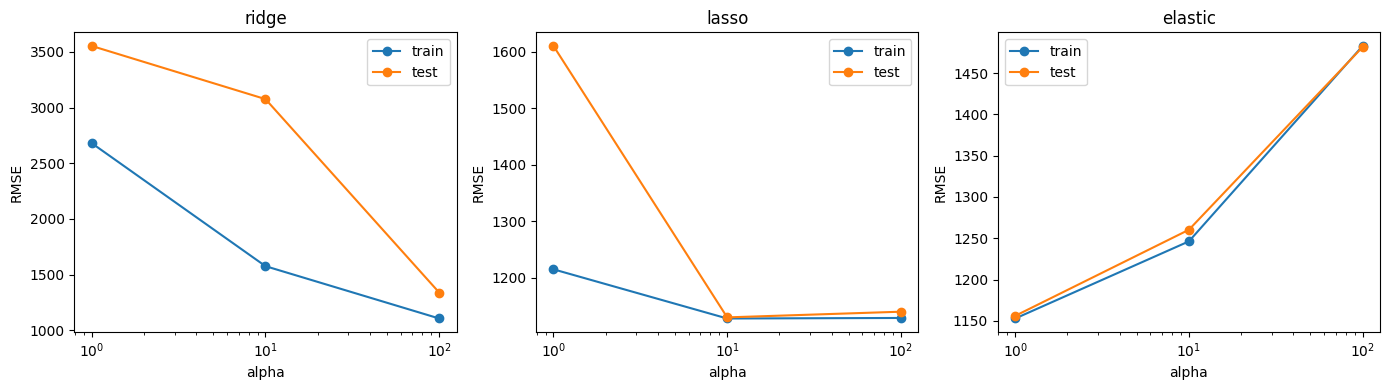

In [285]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, m in zip(axes, ["ridge", "lasso", "elastic"]):
    sub = grid_df[grid_df.model == m]
    ax.plot(sub.alpha, sub.rmse_train, "o-", label="train")
    ax.plot(sub.alpha, sub.rmse_test,  "o-", label="test")
    ax.set_xscale("log"); ax.set_title(m); ax.set_xlabel("alpha"); ax.set_ylabel("RMSE")
    ax.legend()
plt.tight_layout(); plt.show()

## Chapter V.9. Нативные модели — mean и median

In [286]:
mean_pred      = np.full_like(y_train, y_train.mean())
median_pred    = np.full_like(y_train, np.median(y_train))
mean_pred_te   = np.full_like(y_test , y_train.mean())
median_pred_te = np.full_like(y_test , np.median(y_train))

add_metrics("naive_mean",   y_train, mean_pred,   y_test, mean_pred_te)
add_metrics("naive_median", y_train, median_pred, y_test, median_pred_te)

print(f"train mean   = {y_train.mean():.2f}")
print(f"train median = {np.median(y_train):.2f}")

train mean   = 3538.64
train median = 3150.00


## Chapter V.10. Сравнение результатов

In [287]:
def show(df, name):
    print(f"\n=== {name} ===")
    print(df.sort_values("test").to_string(index=False))

show(result_mae , "MAE")
show(result_rmse, "RMSE")
show(result_r2  , "R²")


=== MAE ===
                 model       train         test
       my_lasso_sgd_ss  708.609419   711.233879
      my_linear_sgd_ss  708.643487   711.268828
     my_elastic_sgd_ss  709.390524   711.807047
          my_lasso_sgd  710.247852   712.909115
           sk_lasso_ss  711.389410   714.008979
              sk_lasso  711.397534   714.010505
           sk_lasso_mm  711.649583   714.161866
           sk_ridge_ss  711.787440   714.421945
   my_ridge_analytical  711.787958   714.422138
              sk_ridge  711.787958   714.422138
  my_linear_analytical  711.791166   714.425708
          sk_linear_ss  711.791166   714.425708
          sk_linear_mm  711.791166   714.425708
             sk_linear  711.791166   714.425708
           sk_ridge_mm  711.868658   714.464320
        my_elastic_sgd  714.245933   716.478709
       my_ridge_sgd_ss  714.936415   717.526003
      my_linear_sgd_mm  724.406327   726.464558
       my_lasso_sgd_mm  724.421674   726.474589
          my_ridge_sgd  725

In [288]:
# Топ-5 по RMSE на тесте
result_rmse.sort_values("test").head(5)

,model,train,test
14,sk_ridge_mm,1035.384206,1036.068948
2,my_ridge_analytical,1035.351581,1036.069672
6,sk_ridge,1035.351581,1036.069672
22,sk_ridge_ss,1035.351579,1036.069899
0,my_linear_analytical,1035.351576,1036.070236


In [289]:
stab = result_rmse.copy()
stab["gap"] = (stab["test"] - stab["train"]).abs()
stab.sort_values("gap").head(10)

,model,train,test,gap
9,my_linear_sgd_mm,1058.829377,1058.786702,0.042674
20,my_elastic_sgd_ss,1042.653449,1042.698033,0.044584
11,my_lasso_sgd_mm,1058.953147,1058.898255,0.054891
18,my_ridge_sgd_ss,1051.518075,1051.348019,0.170057
5,my_elastic_sgd,1050.298393,1050.072735,0.225658
28,poly_sk_lasso_a=1,1091.662229,1091.953399,0.291170
15,sk_lasso_mm,1035.775583,1036.224791,0.449208
19,my_lasso_sgd_ss,1035.955215,1036.441324,0.486110
17,my_linear_sgd_ss,1035.953865,1036.447974,0.494108
7,sk_lasso,1035.548536,1036.118979,0.570443


## Итоговая таблица

In [293]:
final = (result_mae.rename(columns={"train":"MAE_train","test":"MAE_test"})
         .merge(result_rmse.rename(columns={"train":"RMSE_train","test":"RMSE_test"}), on="model")
)
final.sort_values("RMSE_test").reset_index(drop=True)

,model,MAE_train,MAE_test,RMSE_train,RMSE_test
0,sk_ridge_mm,711.868658,714.464320,1035.384206,1.036069e+03
1,my_ridge_analytical,711.787958,714.422138,1035.351581,1.036070e+03
2,sk_ridge,711.787958,714.422138,1035.351581,1.036070e+03
3,sk_ridge_ss,711.787440,714.421945,1035.351579,1.036070e+03
4,my_linear_analytical,711.791166,714.425708,1035.351576,1.036070e+03
5,sk_linear_mm,711.791166,714.425708,1035.351576,1.036070e+03
6,sk_linear_ss,711.791166,714.425708,1035.351576,1.036070e+03
7,sk_linear,711.791166,714.425708,1035.351576,1.036070e+03
8,my_lasso_sgd,710.247852,712.909115,1035.442032,1.036102e+03
9,sk_lasso,711.397534,714.010505,1035.548536,1.036119e+03
